In [183]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
# make_blobs : 가상의 클러스터를 생성해줌(가우시안 정규분포를 따름)

In [184]:
# K-means : 끼리끼리 뭉치기
# 랜덤하게 중심점을 잡고, 각 데이터는 가장 가까운 거리가반으로 중심점을 모여 팀을 이룬다.
# 팀원들의 평균 위치로 중심점을 계속 이동시키면서 최적의 뭉치를 찾는다.

In [185]:
centroid=[[3,1],[1,-1],[-3,1]]

In [186]:
X,_=make_blobs(n_samples=1500, centers=centroid)
# X : [n_samples, n_features] 생성된 데이터의 좌표값
print(X)
# y : 각 샘플이 어떤 클러스터에 속하는지 나타내는 정수형 인덱스
# 비지도 학습이기 때문에 정답을 모르는 상태를 가정하려고 y(레이블)을 버린다
#print(y)

[[ 1.54603446 -0.85993626]
 [-3.5468475   1.12721872]
 [ 0.47547794 -0.35340385]
 ...
 [ 4.43056173  1.98319692]
 [ 0.59588936 -0.35730773]
 [ 4.24082635 -0.35564191]]


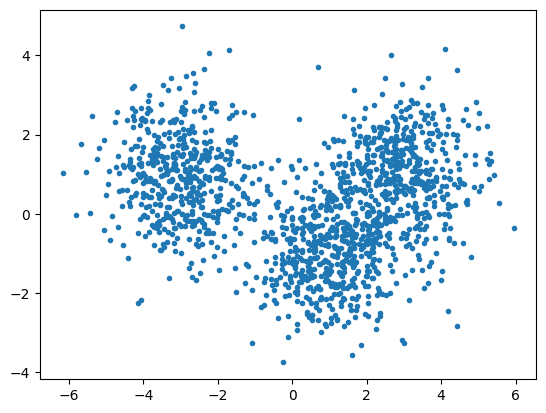

In [187]:
plt.scatter(X[:,0],X[:,1], marker=".")

In [188]:
# 클러스터 개수 지정 -> K-means가 데이터 나눌 그룹 수 설정
ncluster=3

In [189]:
# 3개의 클러스터로 데이터 분할
k_means=KMeans(n_clusters=ncluster)

In [190]:
# 모델 학습시킴(정답 y는 넣지않는다 - 좌표 X만 넣음
k_means.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [191]:
# 데이터들이 자기 그룹의 중심점을 자기들 그룹의 정중앙으로 끌어당기는 과정

# 학습된 결과인 각 데이터의 그룹번호(중심점 - 인덱스)
k_means.labels_

array([2, 1, 2, ..., 0, 2, 0], shape=(1500,), dtype=int32)

In [192]:
# 학습을 통해 찾아낸 최종 중심점 좌표
# 1500개의 데이터를 반복해저 중심점을 계속 이동시키며 최종적으로  찾아낸 각 그룹의 중심점(대장좌표
centers=k_means.cluster_centers_
centers

array([[ 3.00144429,  1.10179087],
       [-3.01760747,  0.94278568],
       [ 0.98278306, -1.0270991 ]])

In [193]:
from matplotlib.colors import ListedColormap

color_bold=ListedColormap(['red','blue','green'])
color_light=ListedColormap(['#FFAAAA','#42e3f5','#42f584'])

In [194]:
# la=np.array([0,1,1,0,2,2])
# i=1

# result=la==i
# print(result)

In [195]:
# X=[[1,2],
#    [5,6],
#    [1.5,5.6],
#    [8,8],
#    [8,4],
#    [2,5]]

# labels=[0,1,0,1,1,0]
# 0번 클러스터 -> [1,2],[1.5,5.6],[2,5]
# 1번 클러스터 -> [5,6],[8,8],[8,4]

# i=0 -> cluster = [true, false, true, false, false, true] 
# => 뽑히는 점 [1,2],[1.5,5.6],[2,5]
# X[cluster,0] -> 1, 1.5, 2
# X[cluster,1] -> 5, 5.6, 5

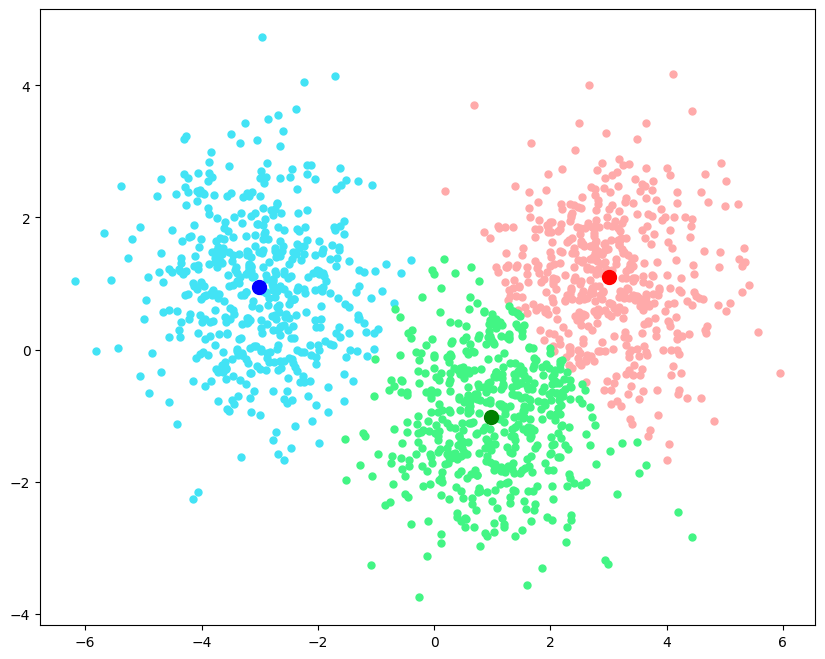

In [196]:
plt.figure(figsize=(10,8))

#i=0 -> 0번째 클러스터에 속하는 데이터만 골라서 x,y좌표로 점 출력
for i in range(ncluster):
    clusters=k_means.labels_ == i
    plt.plot(X[clusters,0], X[clusters, 1], '.', c=color_light(i), markersize=10)
    plt.plot(centers[i,0], centers[i,1], 'o', c=color_bold(i), markersize=10)

In [197]:
from sklearn.cluster import DBSCAN
# 클러스터 개수 미리 지정할 필요 없다 -> 밀집된 점을 클러스터로 그룹화
X1,_=make_blobs(n_samples=500, centers=[[-3,-3]])
X2,_=make_blobs(n_samples=500, centers=[[3,3]])
X3=np.random.rand(500,2)*3+4 # 0~1사이 값 (4~7)
X4=np.random.randn(10,2)*3 # 평균 0 표준편차1인 정규분포 따르는 난수 20개 만들어서 범위를 3배로 줌(-3~3)
print(X1.shape,X2.shape,X3.shape,X4.shape)

(500, 2) (500, 2) (500, 2) (10, 2)


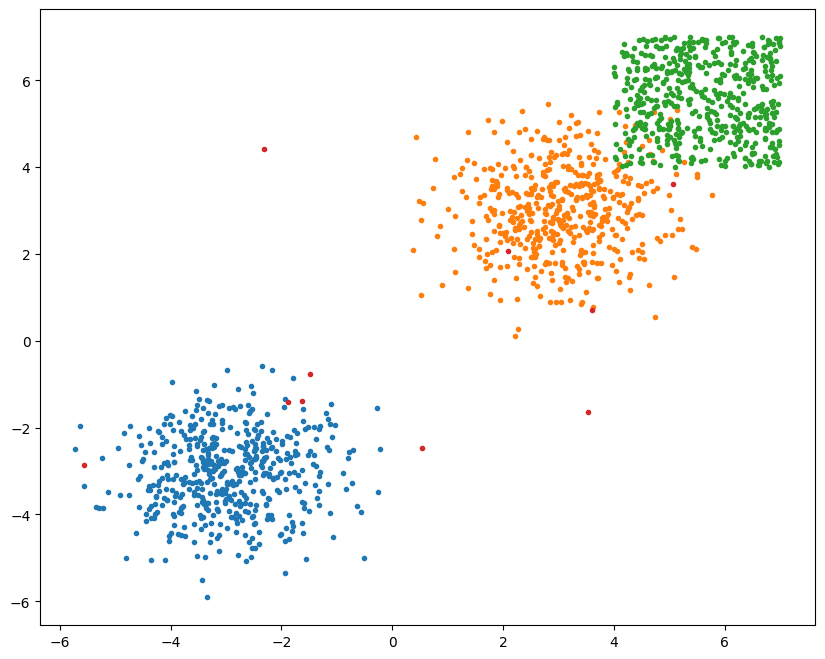

In [198]:
plt.figure(figsize=(10,8))
plt.scatter(X1[:,0], X1[:,1], marker='.')
plt.scatter(X2[:,0], X2[:,1], marker='.')
plt.scatter(X3[:,0], X3[:,1], marker='.')
plt.scatter(X4[:,0], X4[:,1], marker='.')

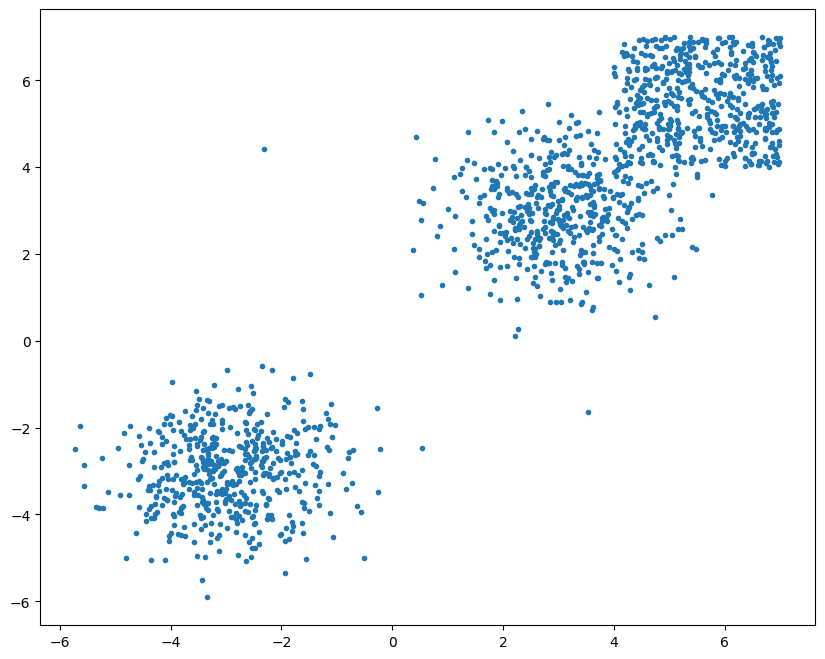

In [199]:
# 네개 데이터셋 다 합치기
# 데이터를 세로(수직)방향으로 쌓기 (vertical stock)
# X:(1510,2)
# 합쳤기 때문에 큰 덩어리로 인식

# 수평방향 hstack
X=np.vstack([X1,X2,X3,X4])

plt.figure(figsize=(10,8))
plt.scatter(X[:,0], X[:,1], marker='.')

In [200]:
X

array([[-2.4509481 , -3.77852974],
       [-3.96570234, -3.43061625],
       [-1.85427928, -3.05395545],
       ...,
       [ 2.09620177,  2.07626446],
       [ 3.53030045, -1.64736588],
       [-2.31006042,  4.41602043]], shape=(1510, 2))

In [201]:
epsilon=0.4 # 반경거리
mininumPoints=8 # core point가 되기위한 최소 점 개수

db=DBSCAN(eps=epsilon, min_samples=mininumPoints).fit(X)
db

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.4
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",8
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [202]:
# 각 점이 어느 그룹에 속하는지
labels=db.labels_
labels

array([ 0,  0,  0, ...,  1, -1, -1], shape=(1510,))

In [203]:
# 핵심점 인덱스 배열
print(db.core_sample_indices_)
# 핵심점 개수(1510 개 중 핵심점 개수)
# 1380 (90% 정도는 데이터가 잘 뭉쳐져 있다)
# 130개 정도는 경계점이거나 노이즈
print(db.core_sample_indices_.shape)

# 조건 까다로울 겨우 -> 핵심정 개수가 작다(500개 정도)
# 조건 널널할 경우 -> 1510에 가깝게 나옴

[   0    1    2 ... 1498 1499 1507]
(1367,)


In [204]:
label1=set(labels)
label1

{np.int64(-1), np.int64(0), np.int64(1)}